# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [2]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 13.99 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
!ls MNIST

processed  raw


In [4]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [5]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [6]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

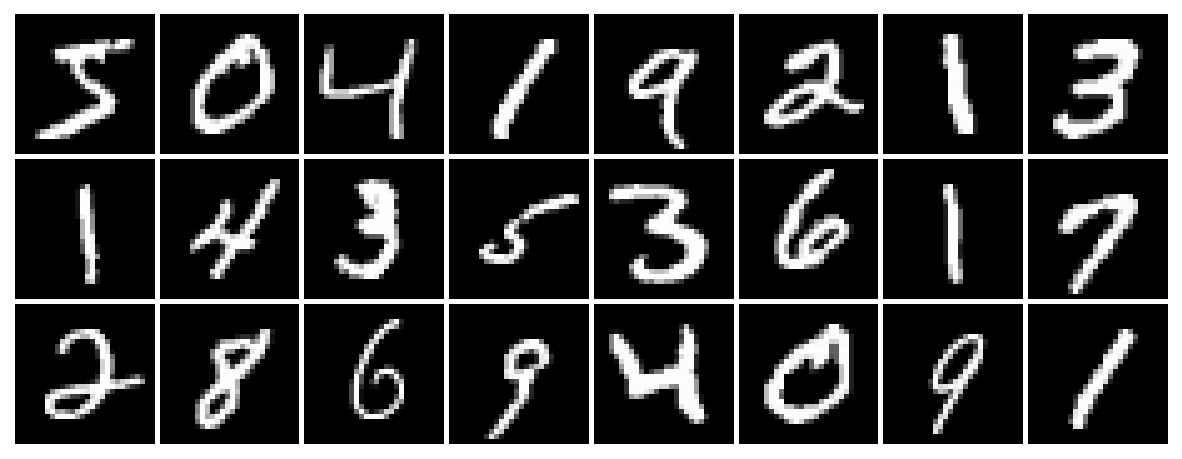

In [7]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


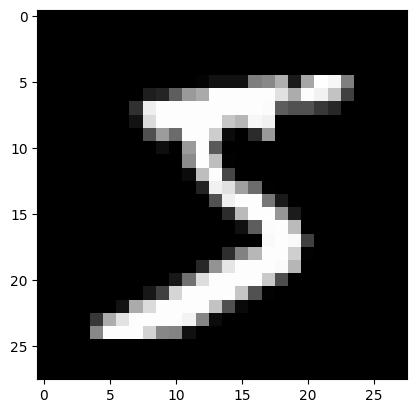

In [8]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [9]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [10]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[-4.9776e-02,  2.8771e-01,  2.8568e-02,  1.0227e-01,  5.8418e-02,
          2.8921e-01,  1.1924e-01,  1.7222e-01,  1.2447e-02, -1.4453e-01],
        [-1.7287e-01,  4.8781e-02,  8.9071e-02, -8.2616e-02,  3.6444e-02,
          1.1234e-01,  9.9403e-02, -2.2602e-02,  1.8329e-01, -1.0810e-01],
        [ 1.6101e-01, -5.4198e-04,  7.4728e-02, -4.2706e-02, -3.7891e-01,
         -1.6784e-01,  1.0625e-01,  9.2054e-02,  1.5038e-04, -7.8824e-02],
        [-1.8181e-01,  6.3890e-02, -4.3291e-02, -2.6721e-03,  1.5438e-01,
         -3.2479e-02,  3.1338e-01, -1.2465e-01,  8.5078e-02,  6.5491e-02],
        [-8.2380e-02, -5.5103e-02, -8.7927e-02, -7.5533e-02,  3.1470e-02,
          5.6411e-02,  3.3382e-02, -2.7243e-01,  3.6556e-02,  1.5579e-02]],
       grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [11]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [12]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [13]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2642, Train Acc: 0.9420, Val Loss: 0.3901, Val Acc: 0.9000
Epoch [2/100], Train Loss: 0.2629, Train Acc: 0.9420, Val Loss: 0.3891, Val Acc: 0.9000
Epoch [3/100], Train Loss: 0.2616, Train Acc: 0.9420, Val Loss: 0.3882, Val Acc: 0.9000
Epoch [4/100], Train Loss: 0.2603, Train Acc: 0.9420, Val Loss: 0.3873, Val Acc: 0.9000
Epoch [5/100], Train Loss: 0.2590, Train Acc: 0.9420, Val Loss: 0.3864, Val Acc: 0.9000
Epoch [6/100], Train Loss: 0.2578, Train Acc: 0.9420, Val Loss: 0.3855, Val Acc: 0.9000
Epoch [7/100], Train Loss: 0.2565, Train Acc: 0.9420, Val Loss: 0.3846, Val Acc: 0.9000
Epoch [8/100], Train Loss: 0.2553, Train Acc: 0.9420, Val Loss: 0.3837, Val Acc: 0.9000
Epoch [9/100], Train Loss: 0.2541, Train Acc: 0.9420, Val Loss: 0.3829, Val Acc: 0.9000
Epoch [10/100], Train Loss: 0.2529, Train Acc: 0.9440, Val Loss: 0.3821, Val Acc: 0.9000
Epoch [11/100], Train Loss: 0.2517, Train Acc: 0.9450, Val Loss: 0.3812, Val Acc: 0.9000
Epoch [12/100], Train Loss: 0.

In [14]:
print('Final loss:', loss.item())

Final loss: 0.26553645730018616


### Visualizando gráfico de perda durante o treinamento

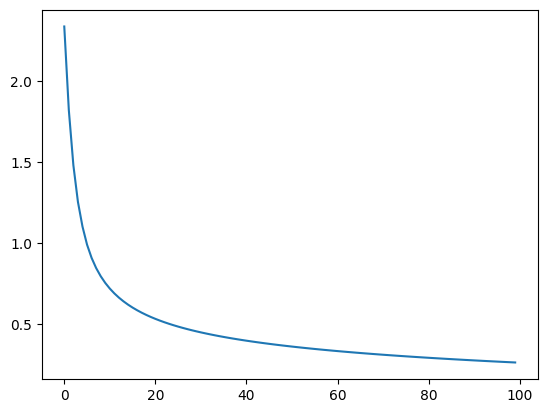

In [15]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

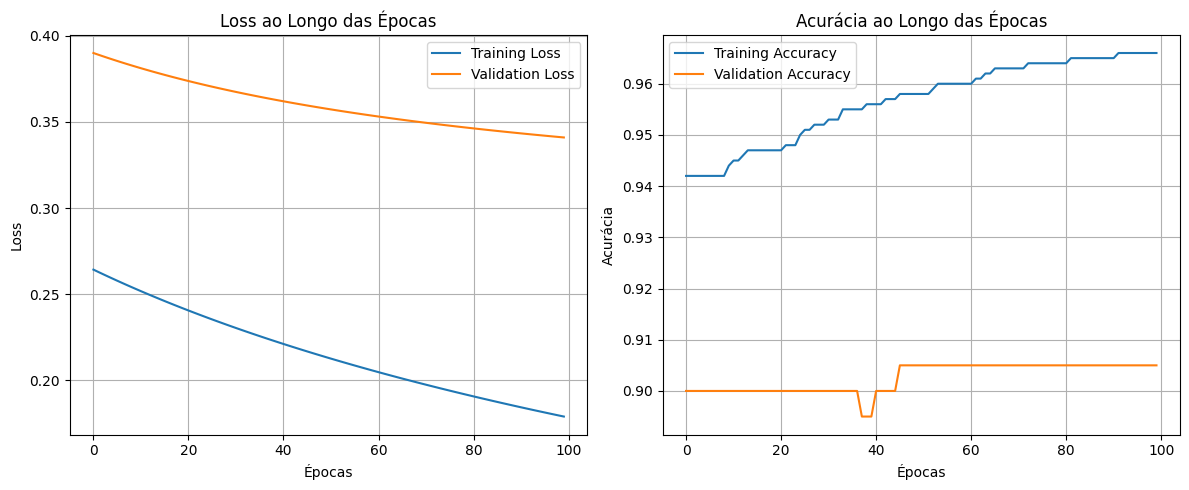

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [17]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.966


### Matriz de confusão com dados de treinamento e teste

In [18]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,1,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,103,1,0,1,0,2
5,0,2,0,1,0,87,0,0,0,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


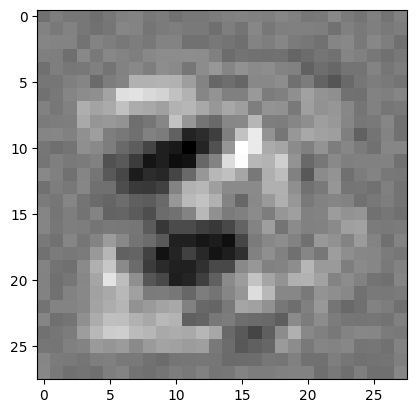

In [19]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

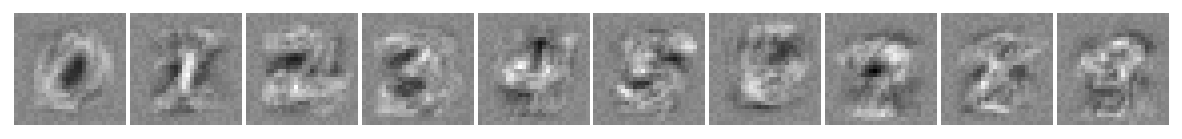

In [20]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

Época [1/100], Perda: 0.1782, Acurácia: 0.9660


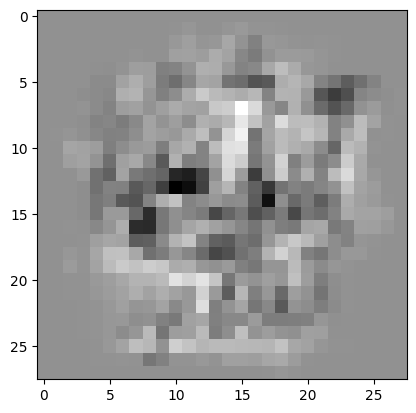

Época [2/100], Perda: 0.1777, Acurácia: 0.9670


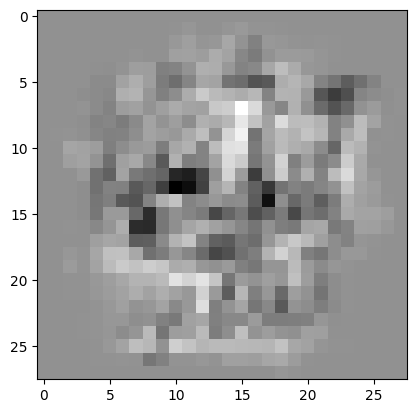

Época [3/100], Perda: 0.1771, Acurácia: 0.9670


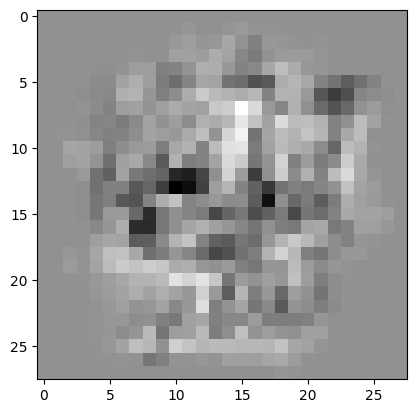

Época [4/100], Perda: 0.1765, Acurácia: 0.9670


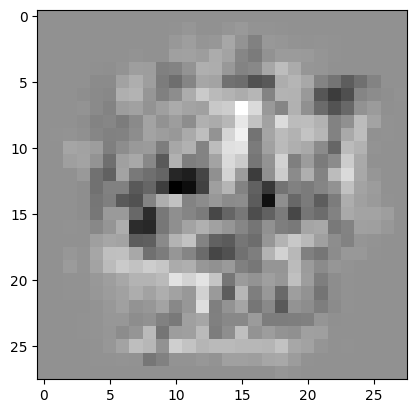

Época [5/100], Perda: 0.1760, Acurácia: 0.9670


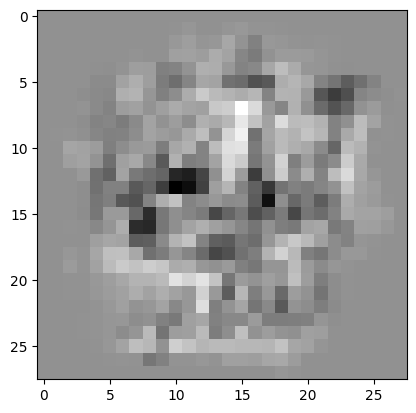

Época [6/100], Perda: 0.1754, Acurácia: 0.9670


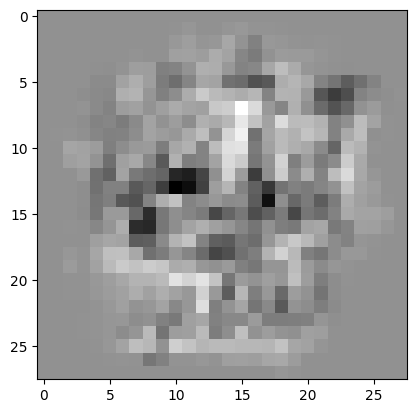

Época [7/100], Perda: 0.1748, Acurácia: 0.9670


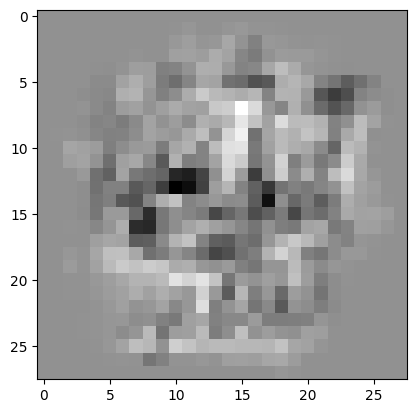

Época [8/100], Perda: 0.1743, Acurácia: 0.9670


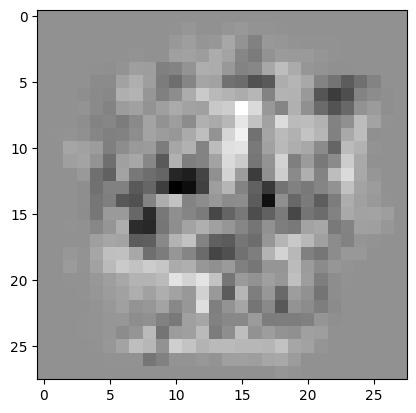

Época [9/100], Perda: 0.1737, Acurácia: 0.9670


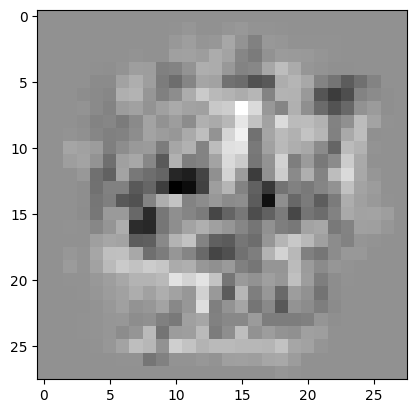

Época [10/100], Perda: 0.1732, Acurácia: 0.9680


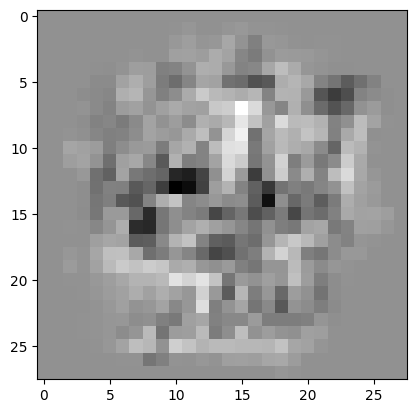

Época [11/100], Perda: 0.1727, Acurácia: 0.9680


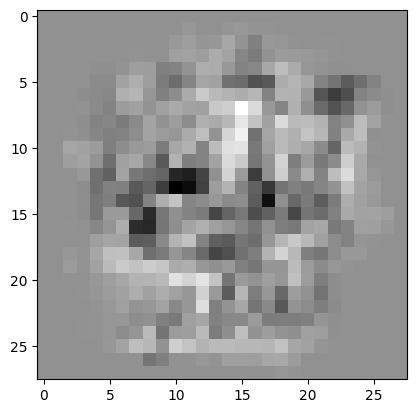

Época [12/100], Perda: 0.1721, Acurácia: 0.9680


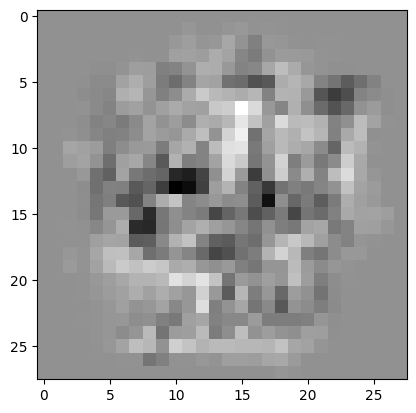

Época [13/100], Perda: 0.1716, Acurácia: 0.9680


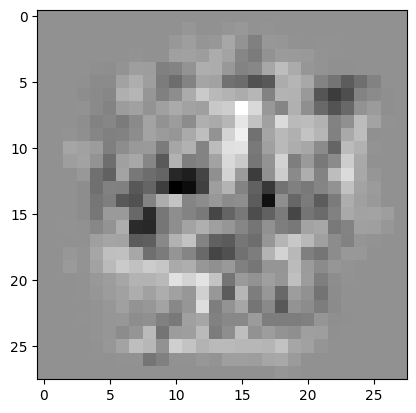

Época [14/100], Perda: 0.1710, Acurácia: 0.9680


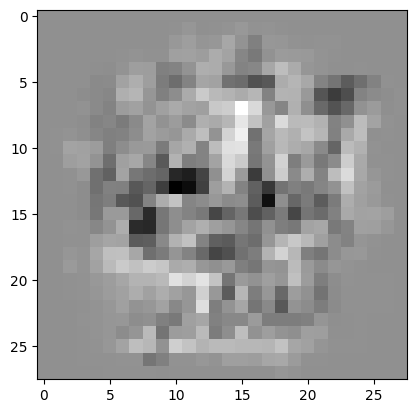

Época [15/100], Perda: 0.1705, Acurácia: 0.9680


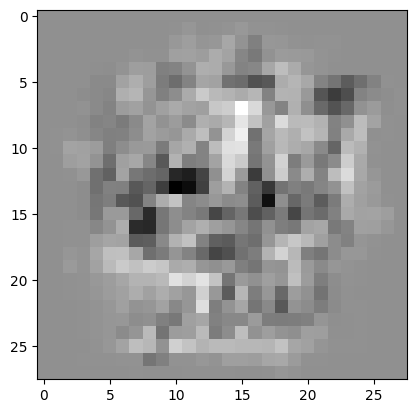

Época [16/100], Perda: 0.1700, Acurácia: 0.9680


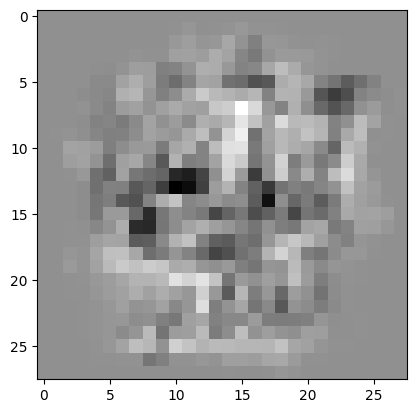

Época [17/100], Perda: 0.1695, Acurácia: 0.9680


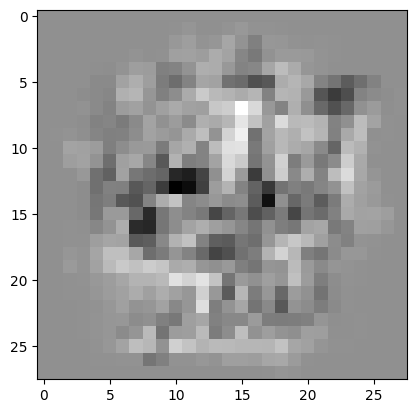

Época [18/100], Perda: 0.1689, Acurácia: 0.9680


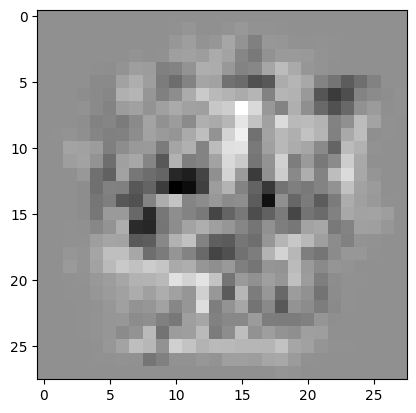

Época [19/100], Perda: 0.1684, Acurácia: 0.9680


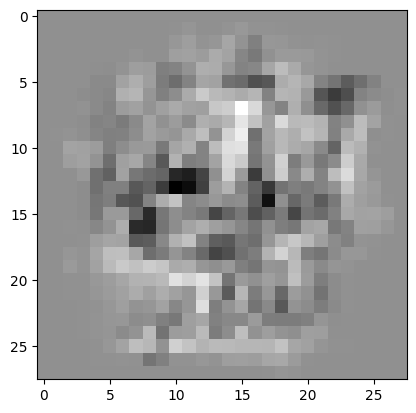

Época [20/100], Perda: 0.1679, Acurácia: 0.9680


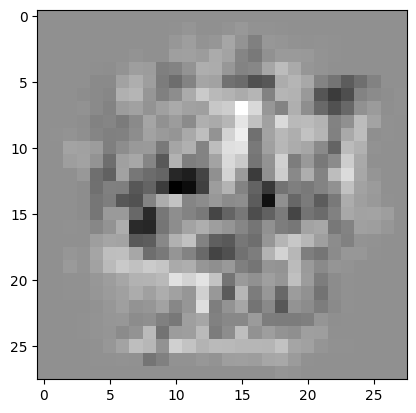

Época [21/100], Perda: 0.1674, Acurácia: 0.9690


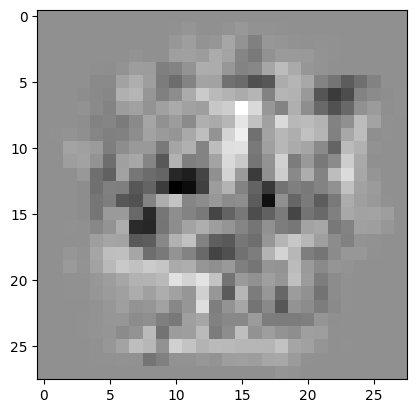

Época [22/100], Perda: 0.1669, Acurácia: 0.9690


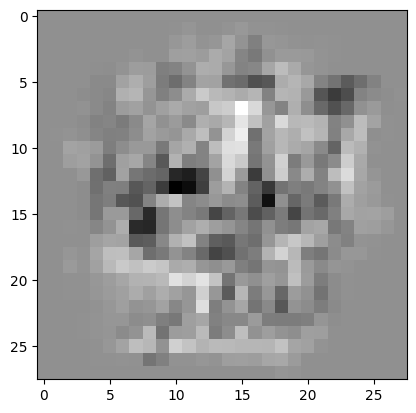

Época [23/100], Perda: 0.1664, Acurácia: 0.9690


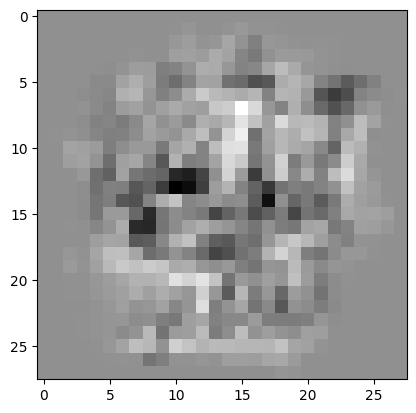

Época [24/100], Perda: 0.1659, Acurácia: 0.9690


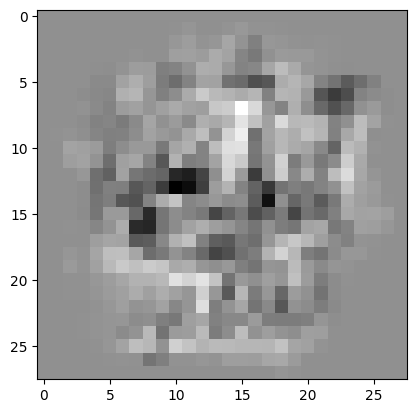

Época [25/100], Perda: 0.1654, Acurácia: 0.9690


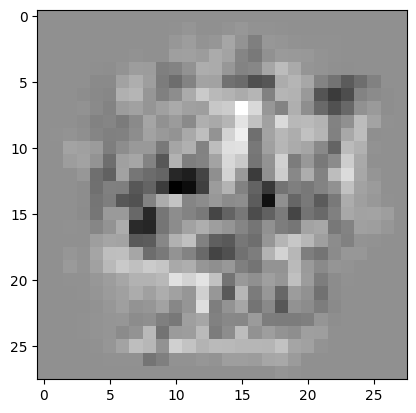

Época [26/100], Perda: 0.1649, Acurácia: 0.9690


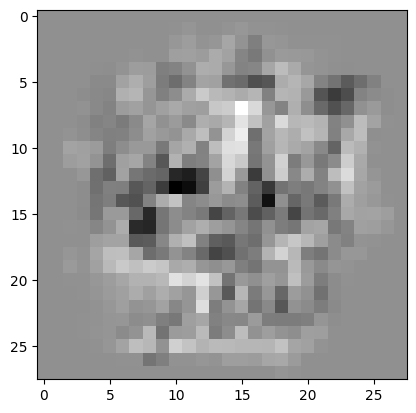

Época [27/100], Perda: 0.1644, Acurácia: 0.9690


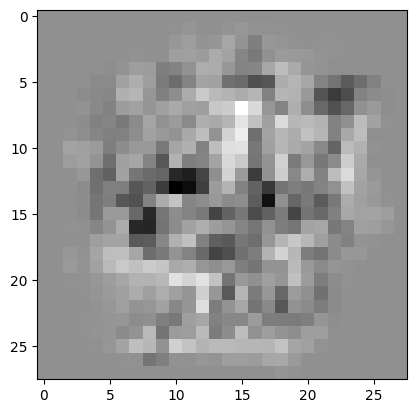

Época [28/100], Perda: 0.1639, Acurácia: 0.9690


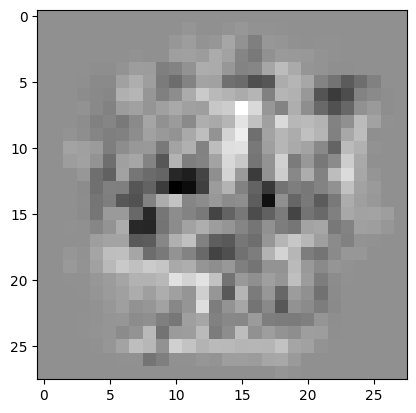

Época [29/100], Perda: 0.1634, Acurácia: 0.9690


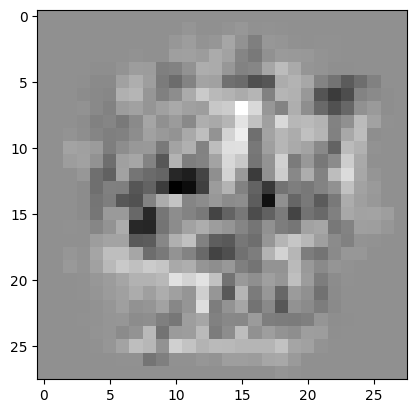

Época [30/100], Perda: 0.1629, Acurácia: 0.9690


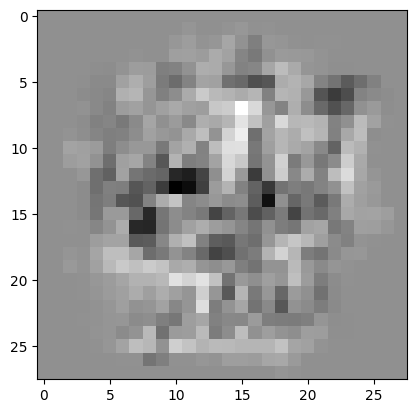

Época [31/100], Perda: 0.1624, Acurácia: 0.9690


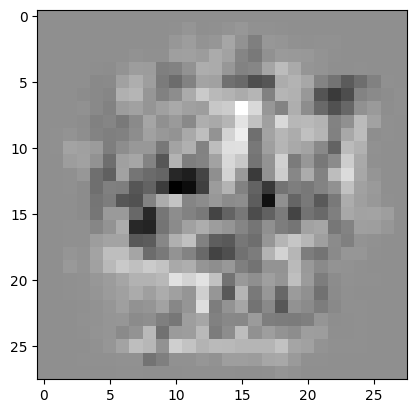

Época [32/100], Perda: 0.1620, Acurácia: 0.9690


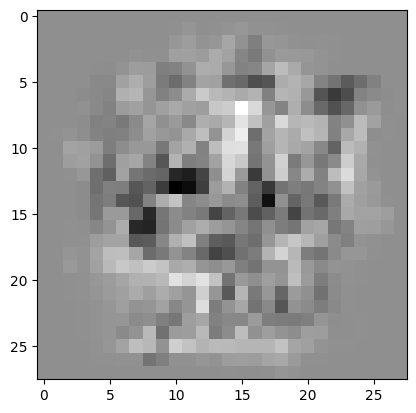

Época [33/100], Perda: 0.1615, Acurácia: 0.9690


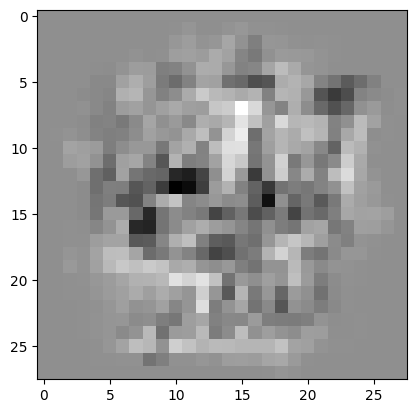

Época [34/100], Perda: 0.1610, Acurácia: 0.9690


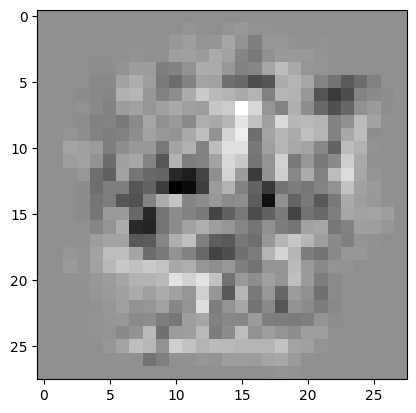

Época [35/100], Perda: 0.1605, Acurácia: 0.9690


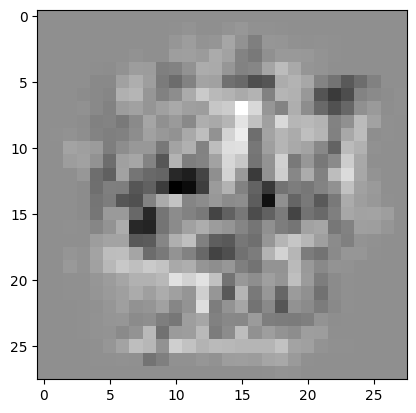

Época [36/100], Perda: 0.1601, Acurácia: 0.9700


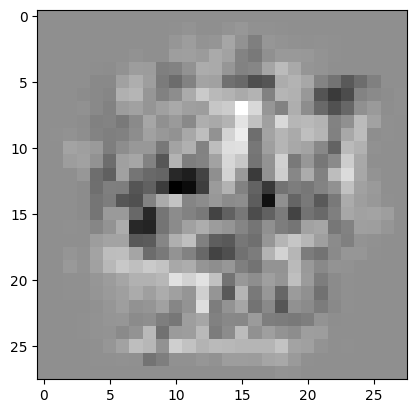

Época [37/100], Perda: 0.1596, Acurácia: 0.9700


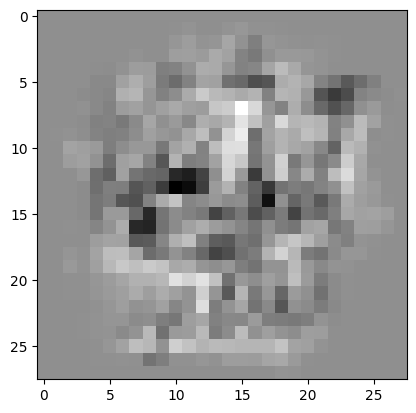

Época [38/100], Perda: 0.1591, Acurácia: 0.9700


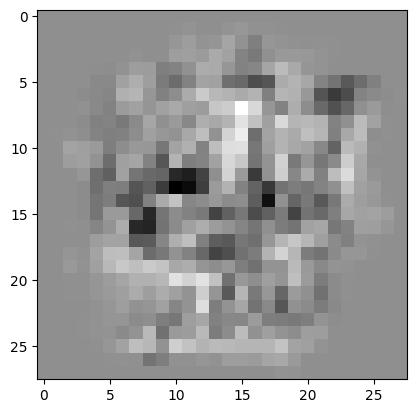

Época [39/100], Perda: 0.1587, Acurácia: 0.9700


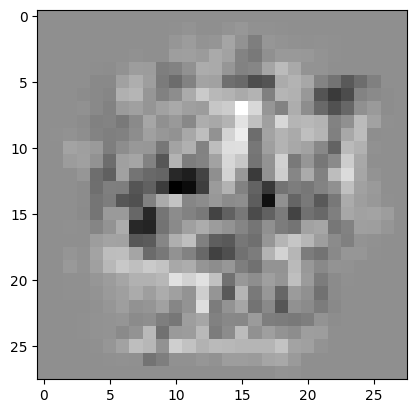

Época [40/100], Perda: 0.1582, Acurácia: 0.9700


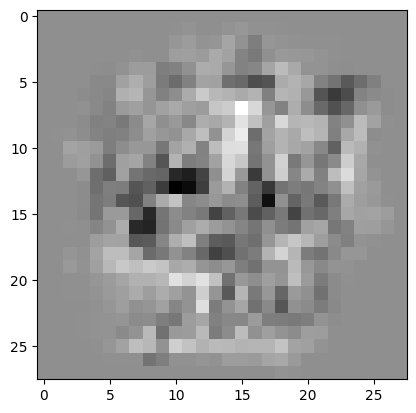

Época [41/100], Perda: 0.1577, Acurácia: 0.9710


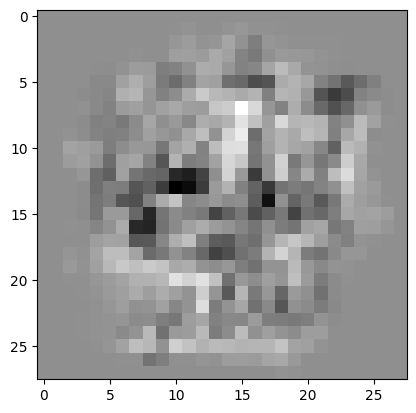

Época [42/100], Perda: 0.1573, Acurácia: 0.9710


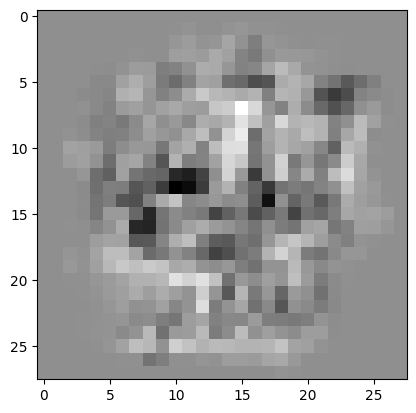

Época [43/100], Perda: 0.1568, Acurácia: 0.9710


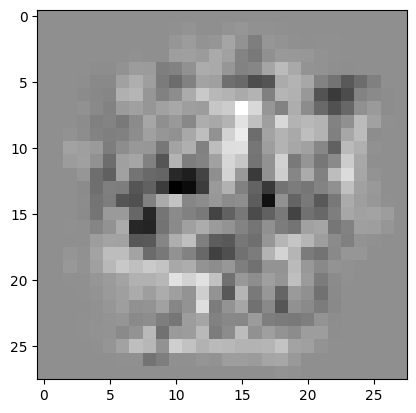

Época [44/100], Perda: 0.1564, Acurácia: 0.9710


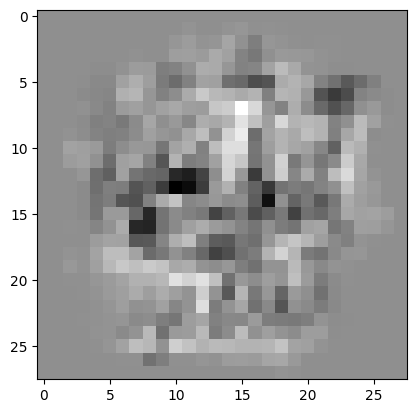

Época [45/100], Perda: 0.1559, Acurácia: 0.9720


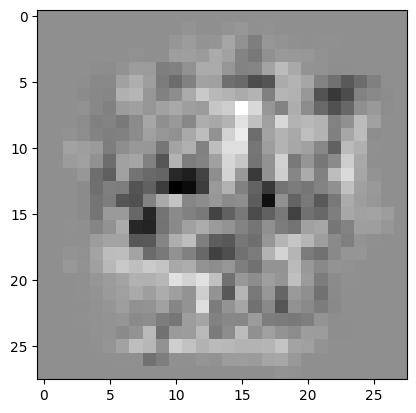

Época [46/100], Perda: 0.1555, Acurácia: 0.9730


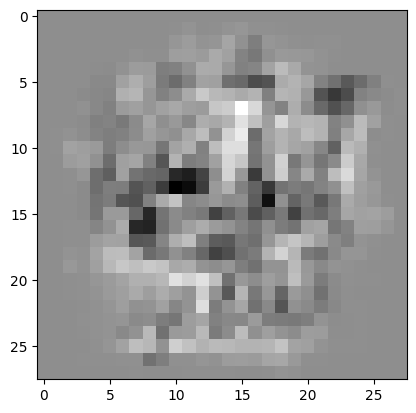

Época [47/100], Perda: 0.1550, Acurácia: 0.9730


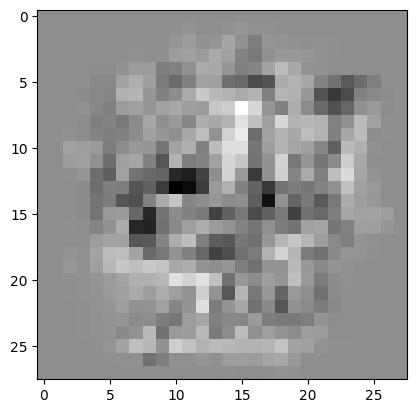

Época [48/100], Perda: 0.1546, Acurácia: 0.9740


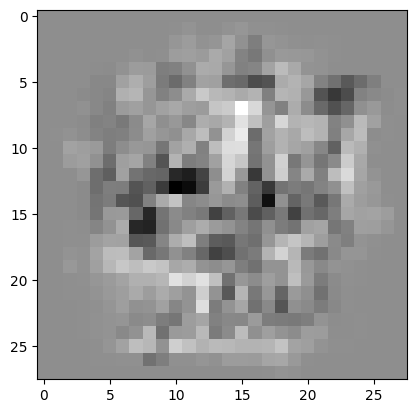

Época [49/100], Perda: 0.1542, Acurácia: 0.9740


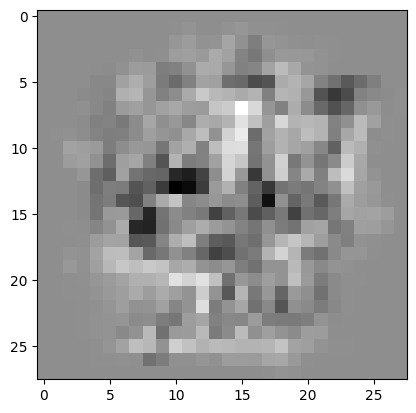

Época [50/100], Perda: 0.1537, Acurácia: 0.9740


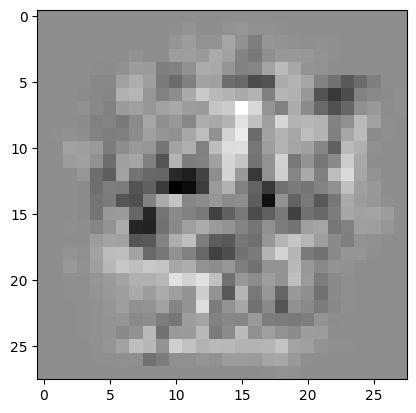

Época [51/100], Perda: 0.1533, Acurácia: 0.9740


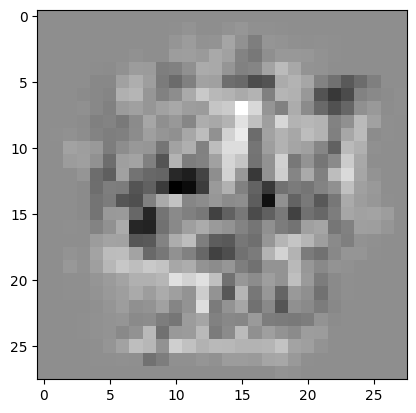

Época [52/100], Perda: 0.1529, Acurácia: 0.9740


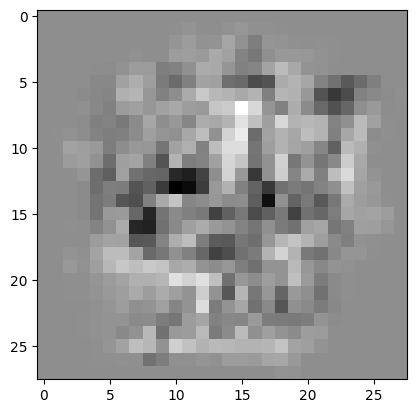

Época [53/100], Perda: 0.1524, Acurácia: 0.9740


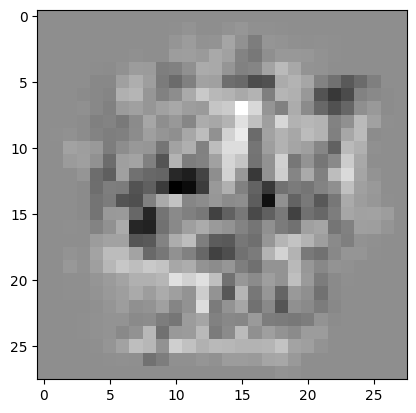

Época [54/100], Perda: 0.1520, Acurácia: 0.9740


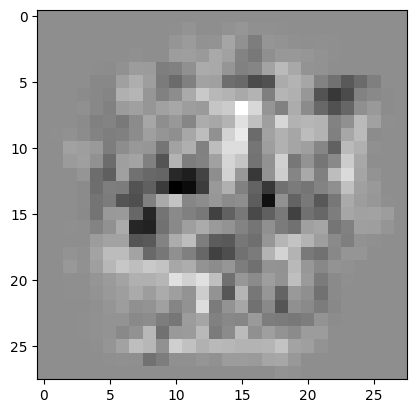

Época [55/100], Perda: 0.1516, Acurácia: 0.9740


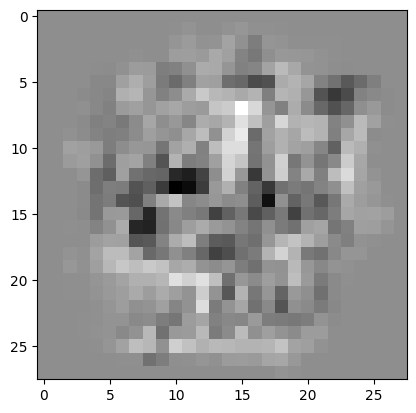

Época [56/100], Perda: 0.1511, Acurácia: 0.9740


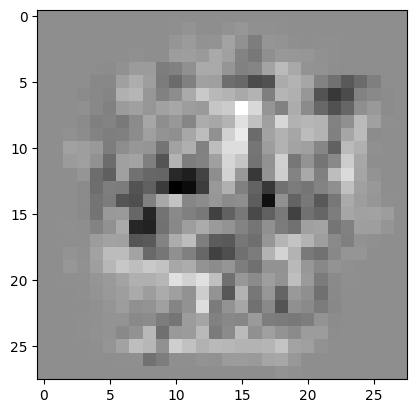

Época [57/100], Perda: 0.1507, Acurácia: 0.9740


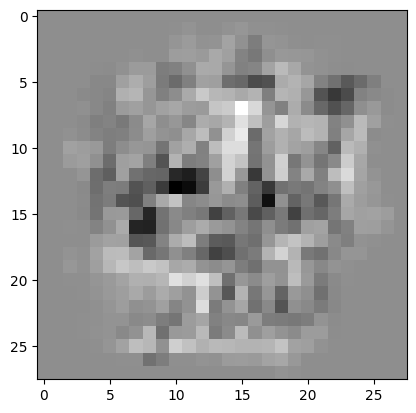

Época [58/100], Perda: 0.1503, Acurácia: 0.9740


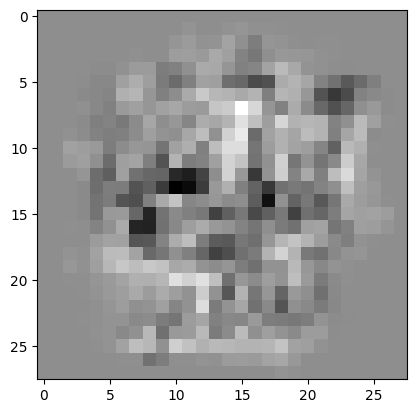

Época [59/100], Perda: 0.1499, Acurácia: 0.9740


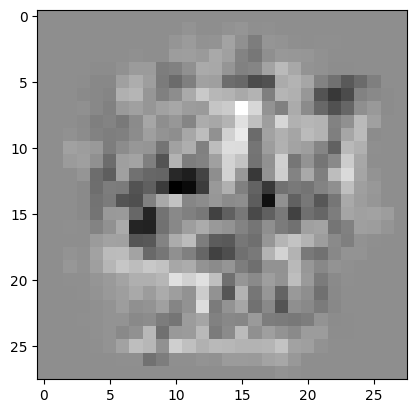

Época [60/100], Perda: 0.1495, Acurácia: 0.9750


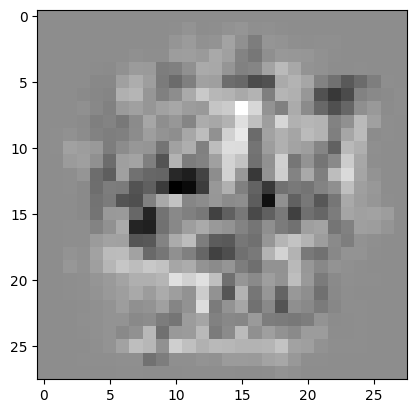

Época [61/100], Perda: 0.1491, Acurácia: 0.9750


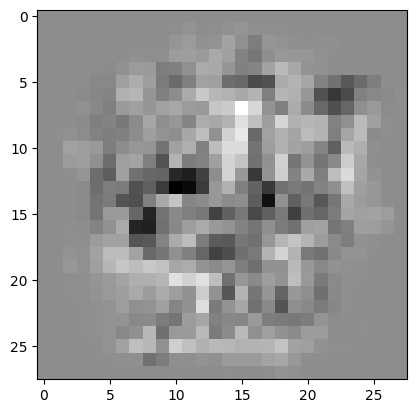

Época [62/100], Perda: 0.1487, Acurácia: 0.9750


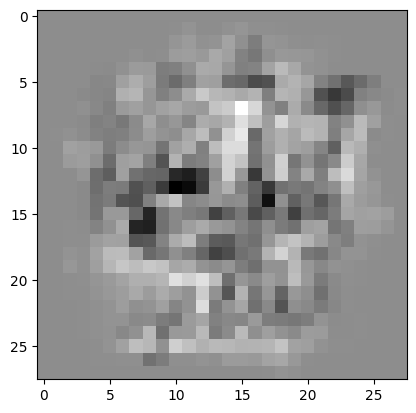

Época [63/100], Perda: 0.1482, Acurácia: 0.9750


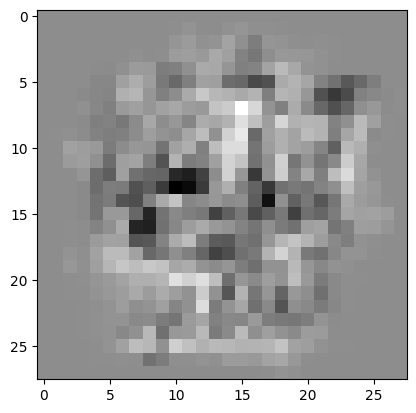

Época [64/100], Perda: 0.1478, Acurácia: 0.9750


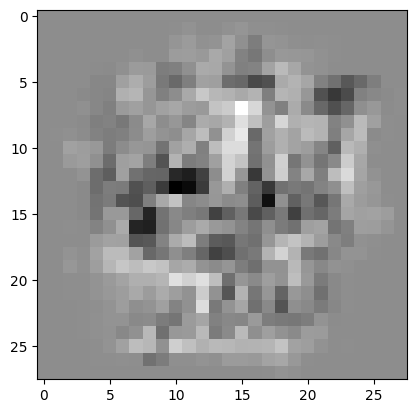

Época [65/100], Perda: 0.1474, Acurácia: 0.9750


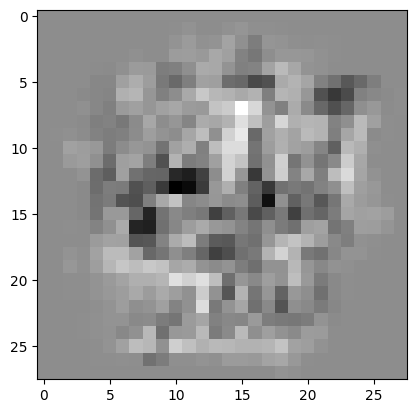

Época [66/100], Perda: 0.1470, Acurácia: 0.9750


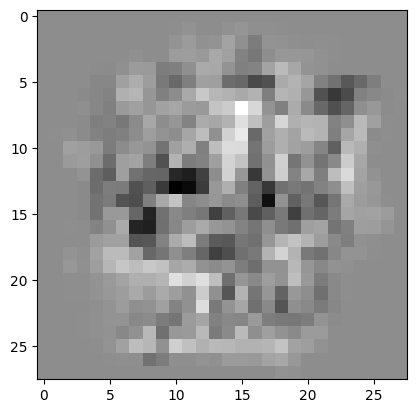

Época [67/100], Perda: 0.1466, Acurácia: 0.9750


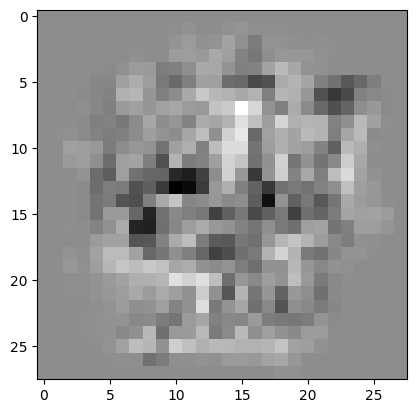

Época [68/100], Perda: 0.1462, Acurácia: 0.9750


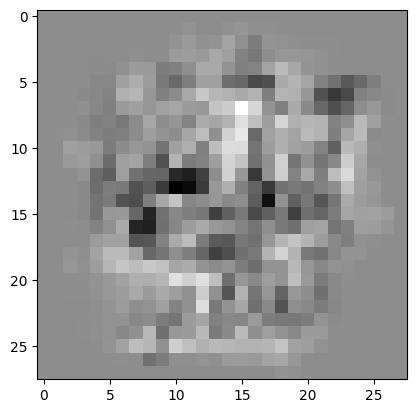

Época [69/100], Perda: 0.1458, Acurácia: 0.9750


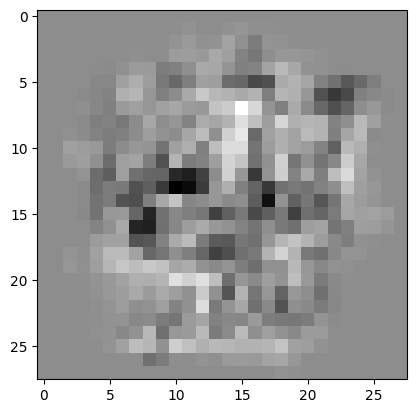

Época [70/100], Perda: 0.1454, Acurácia: 0.9760


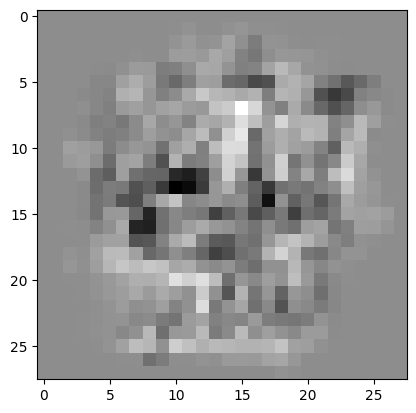

Época [71/100], Perda: 0.1450, Acurácia: 0.9760


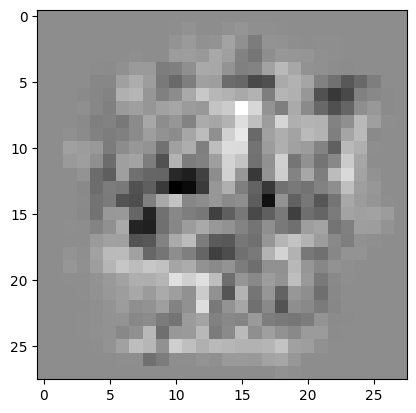

Época [72/100], Perda: 0.1447, Acurácia: 0.9760


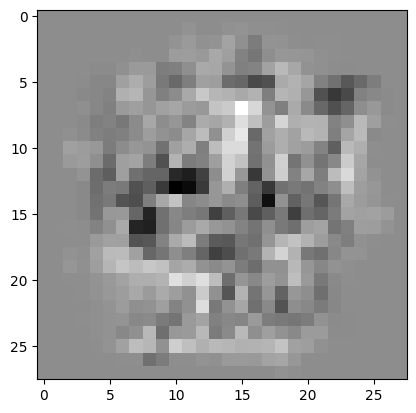

Época [73/100], Perda: 0.1443, Acurácia: 0.9760


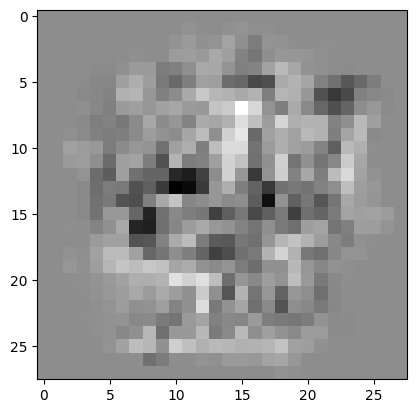

Época [74/100], Perda: 0.1439, Acurácia: 0.9760


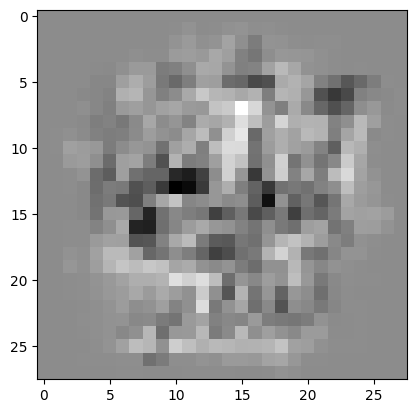

Época [75/100], Perda: 0.1435, Acurácia: 0.9760


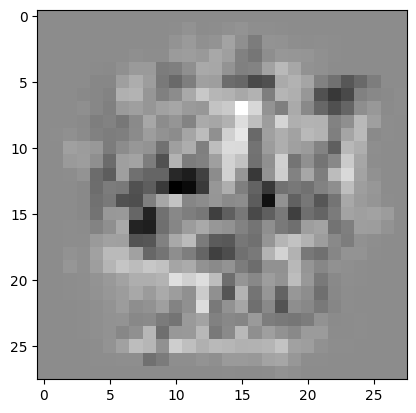

Época [76/100], Perda: 0.1431, Acurácia: 0.9760


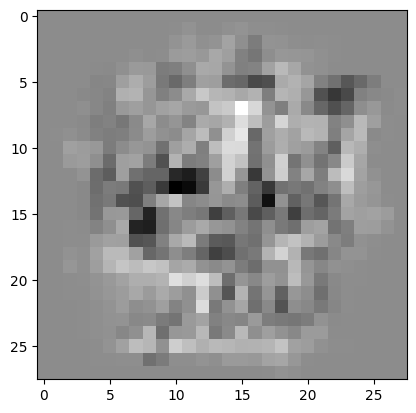

Época [77/100], Perda: 0.1427, Acurácia: 0.9760


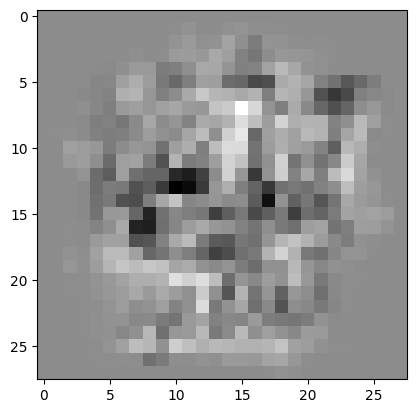

Época [78/100], Perda: 0.1424, Acurácia: 0.9760


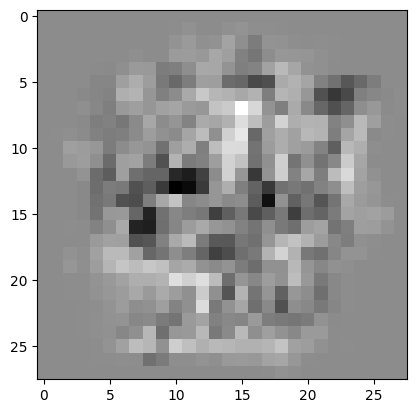

Época [79/100], Perda: 0.1420, Acurácia: 0.9760


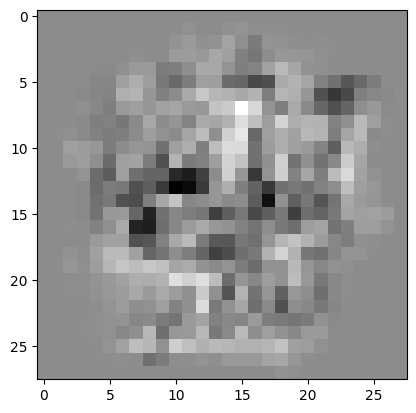

Época [80/100], Perda: 0.1416, Acurácia: 0.9760


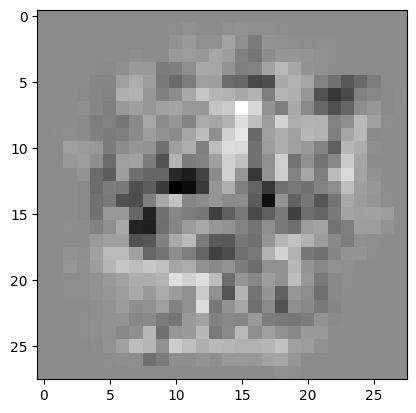

Época [81/100], Perda: 0.1412, Acurácia: 0.9760


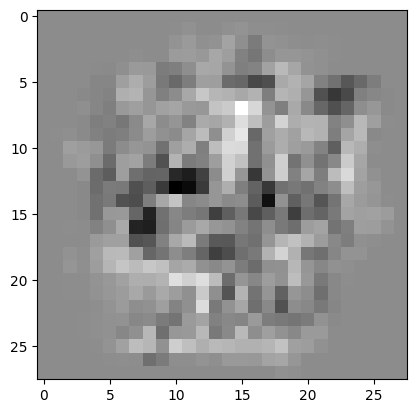

Época [82/100], Perda: 0.1409, Acurácia: 0.9760


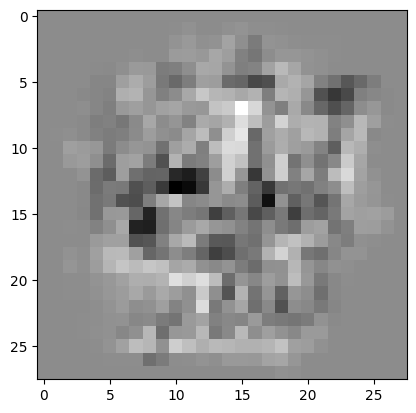

Época [83/100], Perda: 0.1405, Acurácia: 0.9760


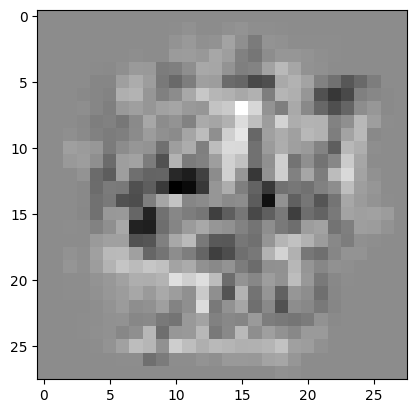

Época [84/100], Perda: 0.1401, Acurácia: 0.9760


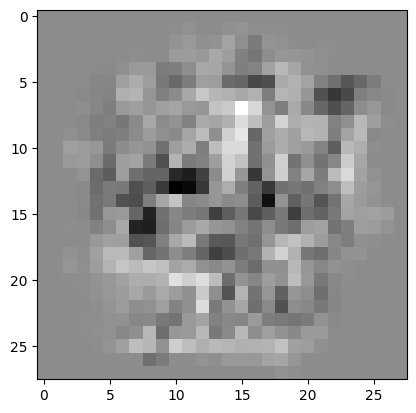

Época [85/100], Perda: 0.1397, Acurácia: 0.9760


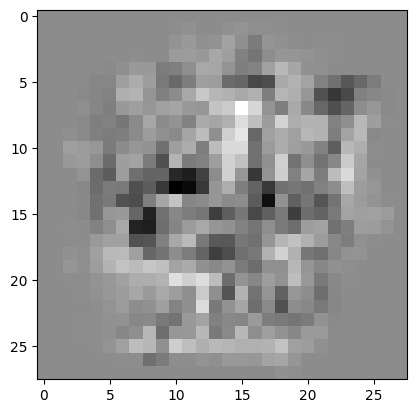

Época [86/100], Perda: 0.1394, Acurácia: 0.9760


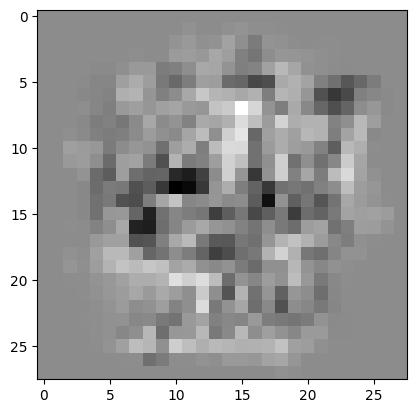

Época [87/100], Perda: 0.1390, Acurácia: 0.9760


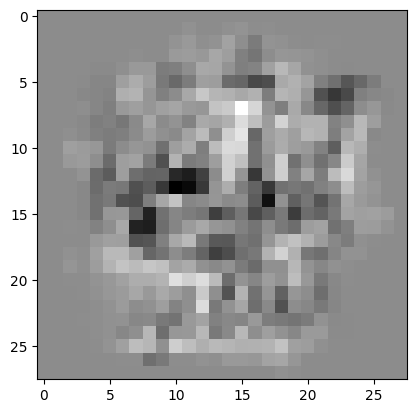

Época [88/100], Perda: 0.1387, Acurácia: 0.9760


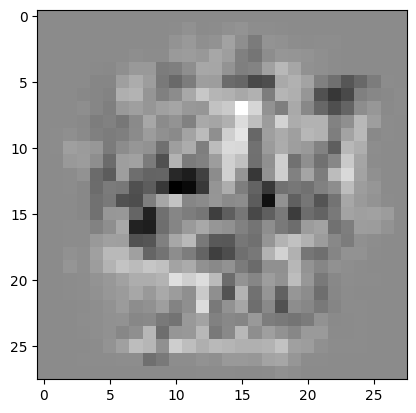

Época [89/100], Perda: 0.1383, Acurácia: 0.9760


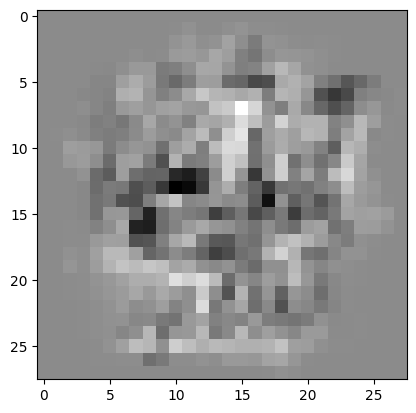

Época [90/100], Perda: 0.1379, Acurácia: 0.9760


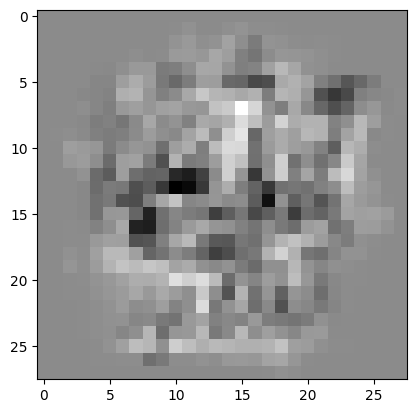

Época [91/100], Perda: 0.1376, Acurácia: 0.9760


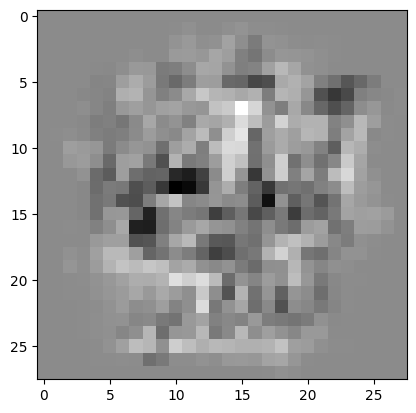

Época [92/100], Perda: 0.1372, Acurácia: 0.9760


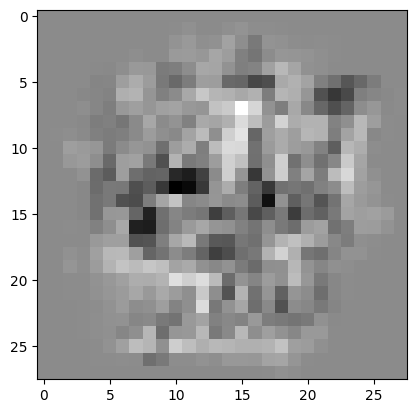

Época [93/100], Perda: 0.1369, Acurácia: 0.9760


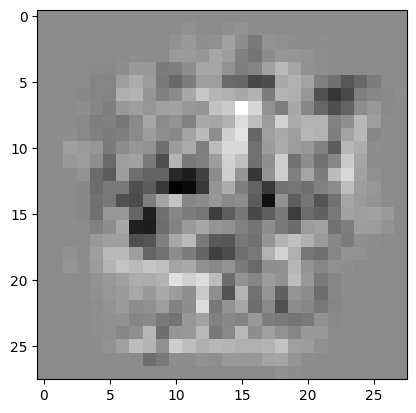

Época [94/100], Perda: 0.1365, Acurácia: 0.9760


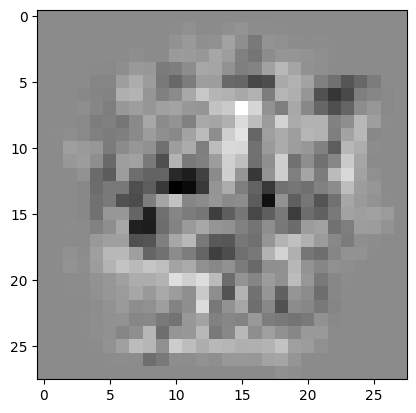

Época [95/100], Perda: 0.1362, Acurácia: 0.9760


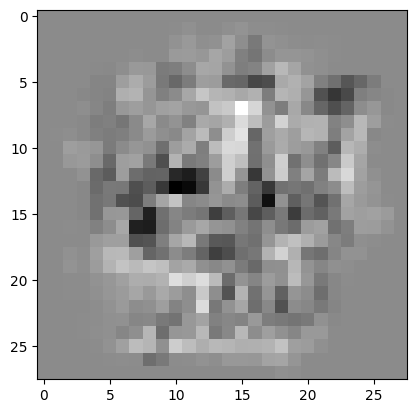

Época [96/100], Perda: 0.1358, Acurácia: 0.9760


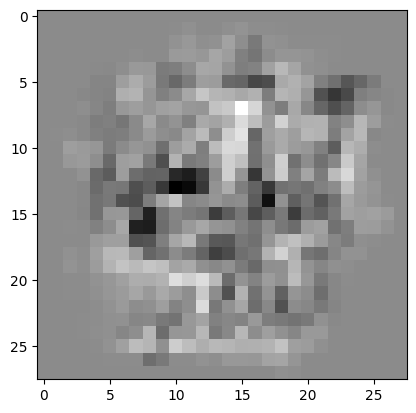

Época [97/100], Perda: 0.1355, Acurácia: 0.9760


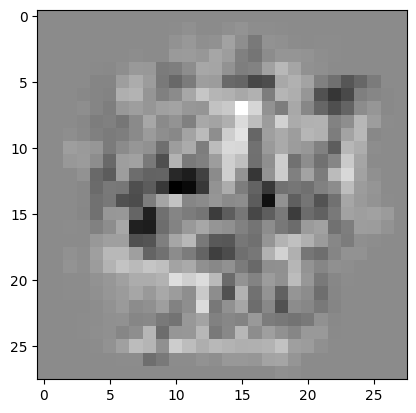

Época [98/100], Perda: 0.1351, Acurácia: 0.9760


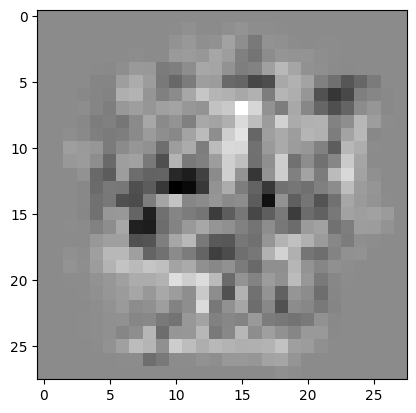

Época [99/100], Perda: 0.1348, Acurácia: 0.9760


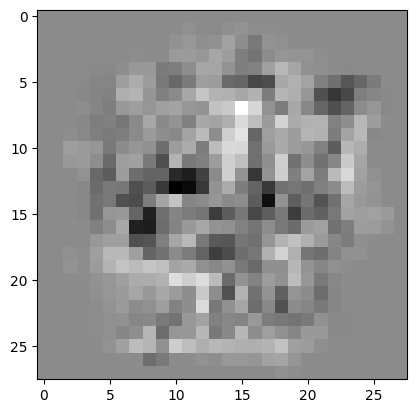

Época [100/100], Perda: 0.1344, Acurácia: 0.9760


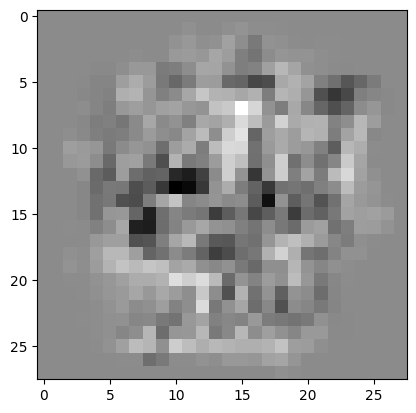

In [21]:
losses = []
zs = []

for i in range(epochs):
    inputs = Variable(x_train.view(-1, 28 * 28))
    outputs = model(inputs)

    zs.append(outputs[1].detach().numpy())

    loss = criterion(outputs, Variable(y_train))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    print(f'Época [{i+1}/{epochs}], Perda: {loss.item():.4f}, Acurácia: {accuracy:.4f}')

    plt.imshow(model.weight.grad[4, :].numpy().reshape((28,28)), cmap='gray')
    plt.show()

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
2. Qual é o shape da saída da rede?
3. Qual é o número total de parâmetros da rede, incluindo o bias?

# Aprendizados
